## Эксперименты
**Обучение на сырых данных**
- Score: $0.7619$

**Добавление фич с помощью метода понижения размерности**
- Score: $0.7615$
- Effect: $-0.0004$
- Значит, не используем

**Добавление фич с помощью метода кластеризации**
- Score: $0.7630$
- Effect: $+0.0011$
- Используем

**Генерация фич**
- Score: $0.7625$
- Effect: $-0.0005$ (учитывая, что добавлена кластеризация)
- Не используем

**Исключение фич, показавших низкую значимость**
- Score: $0.7631$
- Effect: $+0.001$ (учитывая, что добавлена кластеризация)
- Используем

In [1]:
from pathlib import Path
from typing import Optional
from datetime import date, timedelta
import random
import gc

import numpy as np
import polars as pl

from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin

import catboost

SEED = 666
random.seed(SEED)
np.random.seed(SEED)

In [2]:
control_start_date = date(2024, 7, 1)
control_end_date = date(2024, 8, 1)
data_path = Path("/kaggle/input/predict-user-order/")

## Чтение данных

In [3]:
actions_history = pl.read_parquet(data_path / "actions_history")
search_history = pl.read_parquet(data_path / "search_history")
product_information = pl.read_csv(data_path / "product_information.csv")
action_types = pl.read_csv(data_path / "action_type_info.csv")
test_users = pl.read_csv(data_path / "test_users.csv")

In [4]:
action_types

action_type,action_type_id
str,i64
"""click""",1
"""favorite""",2
"""order""",3
"""search""",4
"""to_cart""",5
"""view""",6


Обнаружилось, что в `product_information` довольно много нулевых значений в ценах. Скорее всего, это пропуски

In [5]:
product_information.filter(pl.col("price") == 0)

product_id,name,brand,type,category_id,category_name,price,discount_price
i64,str,str,str,i64,str,f64,f64
1645519130,"""Швабра с отжимом и ведром Ridb…","""Ridberg Home""","""Швабра""",793,"""Швабры, ведра, лопаты""",0.0,0.0
1648642546,"""Святой Источник Светлячок Вода…","""Святой Источник""","""Вода""",228,"""Вода детская""",0.0,0.0
1649304886,"""LIMONI Антивозрастной крем для…","""LIMONI""","""Крем для ухода за кожей""",468,"""Для всех типов кожи""",0.0,0.0
1655110501,"""Кислородный очиститель BRANDFR…","""BRANDFREE""","""Пятновыводитель""",161,"""Пятновыводители""",0.0,0.0
1655302674,"""Набор для уборки GRASS: средст…","""Grass""","""Универсальное чистящее средств…",327,"""Для посуды""",0.0,0.0
…,…,…,…,…,…,…,…
1665110648,"""Салфетки бумажные 1 слоя 24 см…","""Gratias""","""Бумажные салфетки""",301,"""Салфетки бумажные""",0.0,0.0
1667861556,"""Зубная паста детская R.O.C.S. …","""R.O.C.S.""","""Зубная паста""",642,"""Зубные пасты и ополаскиватели""",0.0,0.0
1674778291,"""Доска разделочная 36x24x1,2см …","""BY""","""Разделочная доска""",202,"""Ножи и доски""",0.0,0.0


In [6]:
avg_cat_prices = (
    product_information.filter(pl.col("price") > 0)
    .group_by(pl.col("category_id"))
    .agg(
        pl.col("price").mean().alias("avg_price"),
        pl.col("discount_price").mean().alias("avg_discount_price"),
        pl.col("price").std().alias("std_price"),
        pl.col("discount_price").std().alias("std_discount_price"),
        pl.col("product_id").count().alias("n_products"),
    )
)
avg_cat_prices

category_id,avg_price,avg_discount_price,std_price,std_discount_price,n_products
i64,f64,f64,f64,f64,u32
57,610.797053,459.285774,691.55402,590.543914,133
554,2425.730159,1304.101587,1975.819454,1163.864473,315
313,265.213836,261.540881,240.037006,241.397507,159
658,971.398268,601.125541,827.867804,451.141515,231
3,340.748945,225.0556,424.151265,261.096538,44
…,…,…,…,…,…
110,117.131148,116.196721,40.328433,41.276232,61
476,699.020408,507.469388,568.758058,490.203788,49
303,564.829268,373.707317,243.981342,168.048095,41


не будем заменять эти нули на значения средних по категориям, так как дисперсия цен в категориях довольно высокая. Лучше добавим отдельные фичи со средними ценами по категориям

In [7]:
product_information = product_information.join(
    avg_cat_prices.select(
        "category_id", 
        pl.col("avg_price").alias("category_avg_price"), 
        pl.col("avg_discount_price").alias("category_avg_discount_price")
    ), 
    on="category_id", 
    how="left"
)

In [8]:
product_information

product_id,name,brand,type,category_id,category_name,price,discount_price,category_avg_price,category_avg_discount_price
i64,str,str,str,i64,str,f64,f64,f64,f64
26176363,"""Развивающие тесты (3-4 года) (…","""Machaon""","""Печатная книга: Развитие детей""",780,"""Книги""",380.0,274.0,1191.846573,747.762077
29898500,"""Mexx Туалетная вода Ice Touch …","""Mexx""","""Туалетная вода""",117,"""Мужская""",2645.0,1859.0,2894.742857,1875.761905
33967827,"""64 ГБ USB Флеш-накопитель USB …","""SmartBuy""","""USB-флеш-накопитель""",178,"""Флешки и CD-R""",1690.0,469.0,2423.477874,1017.070061
135938830,"""Чай листовой чёрный Ahmad Tea …","""Ahmad Tea""","""Чай листовой""",465,"""Чай листовой""",319.0,244.0,936.382409,474.432122
137920686,"""Seagate 4 ТБ Внешний жесткий д…","""Seagate""","""Внешний жесткий диск""",615,"""Внешние жесткие диски""",28590.0,9539.0,11641.225317,7135.423678
…,…,…,…,…,…,…,…,…,…
1665110648,"""Салфетки бумажные 1 слоя 24 см…","""Gratias""","""Бумажные салфетки""",301,"""Салфетки бумажные""",0.0,0.0,468.232507,262.299173
1667861556,"""Зубная паста детская R.O.C.S. …","""R.O.C.S.""","""Зубная паста""",642,"""Зубные пасты и ополаскиватели""",0.0,0.0,833.995172,525.196637
1674778291,"""Доска разделочная 36x24x1,2см …","""BY""","""Разделочная доска""",202,"""Ножи и доски""",0.0,0.0,2848.674986,1341.955688


## Подготовка данных

In [9]:
train_df = (
    actions_history.filter(
        pl.col("timestamp") < control_end_date,
        pl.col("timestamp") >= control_start_date,
    )
    .select("user_id", (pl.col("action_type_id") == 3).cast(pl.Int8).alias("target"))
    .group_by("user_id")
    .agg(pl.col("target").max())
)

train_df["target"].value_counts()

target,count
i8,u32
1,647575
0,1227381


In [10]:
product_information

product_id,name,brand,type,category_id,category_name,price,discount_price,category_avg_price,category_avg_discount_price
i64,str,str,str,i64,str,f64,f64,f64,f64
26176363,"""Развивающие тесты (3-4 года) (…","""Machaon""","""Печатная книга: Развитие детей""",780,"""Книги""",380.0,274.0,1191.846573,747.762077
29898500,"""Mexx Туалетная вода Ice Touch …","""Mexx""","""Туалетная вода""",117,"""Мужская""",2645.0,1859.0,2894.742857,1875.761905
33967827,"""64 ГБ USB Флеш-накопитель USB …","""SmartBuy""","""USB-флеш-накопитель""",178,"""Флешки и CD-R""",1690.0,469.0,2423.477874,1017.070061
135938830,"""Чай листовой чёрный Ahmad Tea …","""Ahmad Tea""","""Чай листовой""",465,"""Чай листовой""",319.0,244.0,936.382409,474.432122
137920686,"""Seagate 4 ТБ Внешний жесткий д…","""Seagate""","""Внешний жесткий диск""",615,"""Внешние жесткие диски""",28590.0,9539.0,11641.225317,7135.423678
…,…,…,…,…,…,…,…,…,…
1665110648,"""Салфетки бумажные 1 слоя 24 см…","""Gratias""","""Бумажные салфетки""",301,"""Салфетки бумажные""",0.0,0.0,468.232507,262.299173
1667861556,"""Зубная паста детская R.O.C.S. …","""R.O.C.S.""","""Зубная паста""",642,"""Зубные пасты и ополаскиватели""",0.0,0.0,833.995172,525.196637
1674778291,"""Доска разделочная 36x24x1,2см …","""BY""","""Разделочная доска""",202,"""Ножи и доски""",0.0,0.0,2848.674986,1341.955688


In [11]:
def get_search_aggregation(
    action_id: int,
    action_name: str,
    cutoff_date: date,
    history_depth_months: int,
) -> pl.DataFrame:
    conds = [
        pl.col("action_type_id") == action_id,
        pl.col("timestamp") < cutoff_date,
        pl.col("timestamp") >= cutoff_date - timedelta(days=30 * history_depth_months),
    ]

    transforms = [
        pl.col("action_type_id").count().alias(f"{action_name}_count"),
        pl.col("widget_name_id")
        .mode()
        .first()
        .alias(f"{action_name}_most_common_widget"),
        pl.col("widget_name_id")
        .n_unique()
        .alias(f"{action_name}_count_distinct_widgets"),
        (cutoff_date - pl.col("timestamp").max())
        .dt.total_days()
        .alias(f"{action_name}_last_days"),
        (cutoff_date - pl.col("timestamp").min())
        .dt.total_days()
        .alias(f"{action_name}_first_days"),
    ]

    agg = search_history.filter(*conds).group_by("user_id").agg(*transforms)

    return agg


def get_action_aggregation(
    action_id: int,
    action_name: str,
    cutoff_date: date,
    history_depth_months: int,
) -> pl.DataFrame:
    conds = [
        pl.col("action_type_id") == action_id,
        pl.col("timestamp") < cutoff_date,
        pl.col("timestamp") >= cutoff_date - timedelta(days=30 * history_depth_months),
    ]
    columns = [
        "price",
        "discount_price",
        "category_avg_price",
        "category_avg_discount_price",
    ]
    transforms = [
        transform
        for col_name in columns
        for transform in [
            pl.col(col_name).mean().alias(f"{action_name}_mean_{col_name}"),
            pl.col(col_name).std().alias(f"{action_name}_std_{col_name}"),
            pl.col(col_name).min().alias(f"{action_name}_min_{col_name}"),
            pl.col(col_name).max().alias(f"{action_name}_max_{col_name}"),
        ]
    ]
    transforms.extend(
        [
            pl.col("product_id").count().alias(f"{action_name}_count"),
            (cutoff_date - pl.col("timestamp").max())
            .dt.total_days()
            .alias(f"{action_name}_last_days"),
            (cutoff_date - pl.col("timestamp").min())
            .dt.total_days()
            .alias(f"{action_name}_first_days"),
            (pl.col("price") - pl.col("discount_price"))
            .mean()
            .alias(f"{action_name}_mean_discount_diff"),
            (pl.col("price") - pl.col("discount_price"))
            .std()
            .alias(f"{action_name}_std_discount_diff"),
            (pl.col("price") - pl.col("discount_price"))
            .min()
            .alias(f"{action_name}_min_discount_diff"),
            (pl.col("price") - pl.col("discount_price"))
            .max()
            .alias(f"{action_name}_max_discount_diff"),
            pl.col("category_id")
            .mode()
            .first()
            .alias(f"{action_name}_most_common_category"),
            pl.col("category_id")
            .n_unique()
            .alias(f"{action_name}_count_distinct_categories"),
        ]
    )

    agg = (
        actions_history.filter(*conds)
        .join(
            product_information.select(
                "product_id",
                "category_id",
                "price",
                "discount_price",
                "category_avg_price",
                "category_avg_discount_price",
            ),
            on="product_id",
            how="left",
        )
        .group_by("user_id")
        .agg(*transforms)
    )

    return agg


def get_aggregation_features(
    df: pl.DataFrame,
    cutoff_date: date,
    history_depth_months: float = 8,
) -> pl.DataFrame:
    aggs = []
    for action_name, action_id in list(action_types.iter_rows())[:-1]:
        if action_name == "search":
            agg = get_search_aggregation(
                action_id, action_name, cutoff_date, history_depth_months
            )
        else:
            agg = get_action_aggregation(
                action_id, action_name, cutoff_date, history_depth_months
            )

        aggs.append(agg)

    for agg in aggs:
        df = df.join(agg, on="user_id", how="left")

    return df


In [12]:
train_df = get_aggregation_features(
    train_df, control_start_date, history_depth_months=8
)

## Разбиение данных

In [13]:
labels = train_df.select("target").to_numpy().flatten()

train_ids, eval_ids = train_test_split(
    np.arange(len(train_df)),
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
)

x = train_df.drop(["user_id", "target"]).to_numpy()
np.nan_to_num(x, copy=False, nan=0)

x_train = x[train_ids]
y_train = labels[train_ids]

means = x_train.mean(axis=0, keepdims=True)
stds = x_train.std(axis=0, keepdims=True)

x_train = (x_train - means) / stds
x = (x - means) / stds

## Понижение размерности (5 баллов)
Алгоритмы UMAP и t-SNE слишком дороги по времени на таком большом датасете, поэтому используем PCA

In [ ]:
pca = PCA(n_components=3, random_state=SEED)
embedding = pca.fit_transform(x_train)

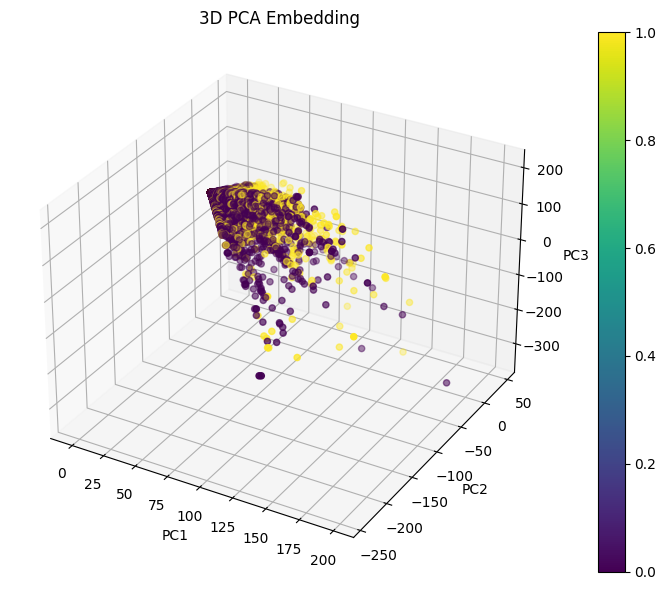

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    embedding[:, 2],
    c=y_train,
    cmap="viridis",
)

ax.set_title("3D PCA Embedding")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(sc)

plt.tight_layout()
plt.show()

Добавление фич с помощью метода понижения размерности

Так как итоговый скор ухудшился, код закомментирован

In [13]:
# pca = PCA(n_components=0.85)
# pca.fit(x)
# embedding = pca.transform(x)


# for i, component in enumerate(embedding.T):
#     train_df = train_df.with_columns(pl.Series(f"pca_{i}", component))

## Кластеризация (5 баллов)

In [15]:
kmeans = KMeans(n_clusters=10, random_state=SEED, n_init=5)
kmeans.fit(x_train)

KMeans(n_clusters=10, n_init=5, random_state=666)

In [16]:
dists = kmeans.transform(x)

for i, dist in enumerate(dists.T):
    train_df = train_df.with_columns(pl.Series(f"kmeans_{i}", dist))

cluster = kmeans.predict(x)
train_df = train_df.with_columns(pl.Series("cluster", cluster))

del dists
del cluster

gc.collect()

0

## Ближайшие Соседи (5 баллов)

В данных слишком много строк, чтобы использовать методы ближайших соседей, а ускорение с помощью приближенных методов, как мне кажется, дадут недостаточно четкие результаты, поэтому пропускаем этот шаг

## Генерация новых фич (5 баллов)

Для генерации новых фич будем использовать полиномиальные фичи, но так как в данных достаточно много колонок, возьмём набор из 100 случайных комбинаций

In [39]:
class RandomizedPolynomialFeatures(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        degree: int = 2,
        n_features: int = 10,
        random_state: Optional[int] = None,
    ):
        self.degree = degree
        self.n_features = n_features
        self.indices = set()
        self.random_state = random_state

    def fit(self, X, y=None) -> "RandomizedPolynomialFeatures":
        unique_counts = []
        for i in range(X.shape[1]):
            unique_counts.append(np.unique(X[:, i]).shape[0])
        unique_counts = np.array(unique_counts)
        
        self.weights = np.log(unique_counts + 1) / np.log(unique_counts + 1).sum()
        if self.random_state is not None:
            np.random.seed(self.random_state)
        self.indices = set()
        for _ in range(self.n_features):
            indices = np.random.choice(
                np.arange(X.shape[1]), size=self.degree, p=self.weights
            )
            while tuple(indices) in self.indices:
                indices = np.random.choice(
                    np.arange(X.shape[1]), size=self.degree, p=self.weights
                )
            self.indices.add(tuple(indices))

        return self

    def transform(self, X) -> np.ndarray:
        X = X.copy()

        new_arr = np.empty((X.shape[0], len(self.indices)))
        for i, indices in enumerate(self.indices):
            new_arr[:, i] = np.prod(X[:, indices], axis=1)

        X = np.hstack([X, new_arr])

        return X


poly = RandomizedPolynomialFeatures(degree=2, n_features=25)
poly.fit(x_train)

RandomizedPolynomialFeatures(n_features=25)

Так как итоговый скор ухудшился, код закомментирован

In [ ]:
# poly_features = poly.transform(x)

# for ids, feature in zip(poly.indices, poly_features.T):
#     train_df = train_df.with_columns(
#         pl.Series("poly_" + "_".join(map(str, ids)), feature)
#     )

# del poly_features

## Итоговые данные

In [16]:
train_df

user_id,target,click_mean_price,click_std_price,click_min_price,click_max_price,click_mean_discount_price,click_std_discount_price,click_min_discount_price,click_max_discount_price,click_mean_category_avg_price,click_std_category_avg_price,click_min_category_avg_price,click_max_category_avg_price,click_mean_category_avg_discount_price,click_std_category_avg_discount_price,click_min_category_avg_discount_price,click_max_category_avg_discount_price,click_count,click_last_days,click_first_days,click_mean_discount_diff,click_std_discount_diff,click_min_discount_diff,click_max_discount_diff,click_most_common_category,click_count_distinct_categories,favorite_mean_price,favorite_std_price,favorite_min_price,favorite_max_price,favorite_mean_discount_price,favorite_std_discount_price,favorite_min_discount_price,favorite_max_discount_price,favorite_mean_category_avg_price,favorite_std_category_avg_price,…,search_first_days,to_cart_mean_price,to_cart_std_price,to_cart_min_price,to_cart_max_price,to_cart_mean_discount_price,to_cart_std_discount_price,to_cart_min_discount_price,to_cart_max_discount_price,to_cart_mean_category_avg_price,to_cart_std_category_avg_price,to_cart_min_category_avg_price,to_cart_max_category_avg_price,to_cart_mean_category_avg_discount_price,to_cart_std_category_avg_discount_price,to_cart_min_category_avg_discount_price,to_cart_max_category_avg_discount_price,to_cart_count,to_cart_last_days,to_cart_first_days,to_cart_mean_discount_diff,to_cart_std_discount_diff,to_cart_min_discount_diff,to_cart_max_discount_diff,to_cart_most_common_category,to_cart_count_distinct_categories,kmeans_0,kmeans_1,kmeans_2,kmeans_3,kmeans_4,kmeans_5,kmeans_6,kmeans_7,kmeans_8,kmeans_9,cluster
i32,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,i64,i64,f64,f64,f64,f64,i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,i64,i64,f64,f64,f64,f64,i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
6703432,0,419.013746,679.975065,46.0,4480.0,356.975945,573.781764,41.0,3899.0,486.76086,549.314859,85.309524,6653.622074,377.320855,396.186308,79.411565,4868.889632,293,0,117,62.037801,235.002323,0.0,2949.0,678,120,697.5,799.268415,184.0,2595.0,656.125,761.391665,179.0,2449.0,799.975131,756.976391,…,121,222.836066,332.334237,42.0,3899.0,195.44918,321.120322,41.0,3899.0,350.688122,308.960078,85.309524,2516.118469,267.211586,209.417251,79.411565,1712.603933,305,0,117,27.386885,54.620471,0.0,383.0,212,105,9.202357,44.247745,10.761841,23.980461,75.748753,68.423245,77.470009,7.767782,2438.088145,33.301638,7
6273110,1,361.607843,327.115397,58.0,1099.0,326.843137,296.309998,46.0,996.0,522.717547,319.841928,85.309524,1157.660377,417.118513,282.223791,79.411565,1031.981132,51,4,95,34.764706,84.489665,0.0,511.0,308,24,103.0,46.669048,70.0,136.0,83.5,53.033009,46.0,121.0,364.090664,216.563072,…,109,201.315789,209.613054,41.0,1099.0,188.921053,198.634993,41.0,996.0,322.786338,285.782315,85.309524,947.940367,270.676879,233.693237,79.411565,836.82381,76,4,95,12.394737,33.825465,0.0,180.0,404,31,4.474366,45.964903,6.259255,23.284947,75.631558,69.006491,76.480632,4.758666,2439.01746,32.621625,0
2593199,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.223421,47.20898,0.651165,23.671118,76.189806,69.772767,77.164658,9.057262,2439.335332,34.299581,2
5222536,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.223421,47.20898,0.651165,23.671118,76.189806,69.772767,77

In [17]:
all_features = train_df.columns
for feat in ["user_id", "target"]:
    all_features.remove(feat)

categorical_features = [
    "click_most_common_category",
    "favorite_most_common_category",
    "to_cart_most_common_category",
    "order_most_common_category",
    "search_most_common_widget",
    "cluster",
]

numerical_features = train_df.columns
for feat in categorical_features + ["user_id", "target"]:
    numerical_features.remove(feat)

In [18]:
train_df = train_df.to_pandas()
train_df[categorical_features] = train_df[categorical_features].astype(str)

In [19]:
train_pool = catboost.Pool(
    train_df.loc[train_ids, all_features],
    train_df.loc[train_ids, "target"],
    cat_features=categorical_features,
)
eval_pool = catboost.Pool(
    train_df.loc[eval_ids, all_features],
    train_df.loc[eval_ids, "target"],
    cat_features=categorical_features,
)

## Обучение CatBoost

In [20]:
model = catboost.CatBoostClassifier(
    iterations=250,
    learning_rate=0.1,
    depth=10,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=5,
    use_best_model=True,
    early_stopping_rounds=50,
    random_seed=SEED,
)

model.fit(train_pool, eval_set=eval_pool)

0:	test: 0.7498986	best: 0.7498986 (0)	total: 5.06s	remaining: 20m 59s
5:	test: 0.7548496	best: 0.7548496 (5)	total: 24.8s	remaining: 16m 50s
10:	test: 0.7568044	best: 0.7568044 (10)	total: 46.6s	remaining: 16m 53s
15:	test: 0.7583509	best: 0.7583509 (15)	total: 1m 8s	remaining: 16m 38s
20:	test: 0.7592429	best: 0.7592429 (20)	total: 1m 29s	remaining: 16m 19s
25:	test: 0.7596743	best: 0.7596743 (25)	total: 1m 51s	remaining: 15m 56s
30:	test: 0.7601608	best: 0.7601608 (30)	total: 2m 11s	remaining: 15m 29s
35:	test: 0.7605569	best: 0.7605569 (35)	total: 2m 33s	remaining: 15m 11s
40:	test: 0.7608231	best: 0.7608231 (40)	total: 2m 53s	remaining: 14m 45s
45:	test: 0.7610206	best: 0.7610206 (45)	total: 3m 13s	remaining: 14m 17s
50:	test: 0.7612023	best: 0.7612023 (50)	total: 3m 33s	remaining: 13m 54s
55:	test: 0.7613270	best: 0.7613270 (55)	total: 3m 52s	remaining: 13m 26s
60:	test: 0.7614291	best: 0.7614291 (60)	total: 4m 14s	remaining: 13m 8s
65:	test: 0.7616078	best: 0.7616078 (65)	total:

## Интерпретация модели (5 баллов)
Посмотрим на важность фич. Если какие-то из них окажутся неважными, то можно попробовать их исключить и обучить модель заново

In [21]:
feature_importance = model.get_feature_importance(prettified=True)
feature_importance.head(10)

,Feature Id,Importances
0,order_count,8.826673
1,order_std_discount_price,7.881533
2,order_last_days,7.483053
3,order_first_days,5.002377
4,to_cart_count,4.065403
5,search_most_common_widget,3.645218
6,search_count,3.449796
7,to_cart_last_days,3.438263
8,order_max_category_avg_price,2.831036
9,click_count_distinct_categories,2.276089


In [24]:
feature_importance.tail(30)

,Feature Id,Importances
86,favorite_min_price,0.211704
87,order_min_price,0.210174
88,favorite_last_days,0.209219
89,click_max_discount_price,0.194806
90,order_mean_discount_diff,0.192370
91,favorite_most_common_category,0.182312
92,kmeans_5,0.178578
93,click_max_price,0.176073
94,to_cart_min_discount_diff,0.172332
95,favorite_std_category_avg_price,0.160733


In [25]:
features_to_remove = feature_importance[feature_importance["Importances"] < 0.2][
    "Feature Id"
].tolist()

for feat in features_to_remove:
    all_features.remove(feat)

    if feat in categorical_features:
        categorical_features.remove(feat)

del train_pool
del eval_pool

train_pool = catboost.Pool(
    train_df.loc[train_ids, all_features],
    train_df.loc[train_ids, "target"],
    cat_features=categorical_features,
)

eval_pool = catboost.Pool(
    train_df.loc[eval_ids, all_features],
    train_df.loc[eval_ids, "target"],
    cat_features=categorical_features,
)

In [26]:
model_pruned = catboost.CatBoostClassifier(
    iterations=250,
    learning_rate=0.1,
    depth=10,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=5,
    use_best_model=True,
    early_stopping_rounds=50,
    random_seed=SEED,
)

model_pruned.fit(train_pool, eval_set=eval_pool)

0:	test: 0.7513996	best: 0.7513996 (0)	total: 3.56s	remaining: 14m 47s
5:	test: 0.7556167	best: 0.7556167 (5)	total: 20.5s	remaining: 13m 55s
10:	test: 0.7567348	best: 0.7567348 (10)	total: 38.4s	remaining: 13m 55s
15:	test: 0.7582704	best: 0.7582704 (15)	total: 56.5s	remaining: 13m 45s
20:	test: 0.7589480	best: 0.7589480 (20)	total: 1m 13s	remaining: 13m 21s
25:	test: 0.7595795	best: 0.7595795 (25)	total: 1m 31s	remaining: 13m 6s
30:	test: 0.7601870	best: 0.7601870 (30)	total: 1m 48s	remaining: 12m 49s
35:	test: 0.7604860	best: 0.7604860 (35)	total: 2m 6s	remaining: 12m 32s
40:	test: 0.7608836	best: 0.7608836 (40)	total: 2m 24s	remaining: 12m 14s
45:	test: 0.7610081	best: 0.7610081 (45)	total: 2m 41s	remaining: 11m 56s
50:	test: 0.7612058	best: 0.7612058 (50)	total: 2m 58s	remaining: 11m 34s
55:	test: 0.7613522	best: 0.7613522 (55)	total: 3m 15s	remaining: 11m 18s
60:	test: 0.7615266	best: 0.7615266 (60)	total: 3m 33s	remaining: 11m
65:	test: 0.7616126	best: 0.7616642 (63)	total: 3m 5

Исключение фич, показавших низкую значимость увеличило скор, так что предсказания будем делать с помощью `model_pruned`

## Предсказание на тестовых данных

In [ ]:
test_users = test_users.with_columns(
    pl.Series("user_id", test_users["user_id"].cast(pl.Int32))
)

In [17]:
test_df = get_aggregation_features(test_users, control_end_date, history_depth_months=8)

In [19]:
x_test = test_df.drop("user_id").to_numpy()
np.nan_to_num(x_test, copy=False, nan=0)
x_test = (x_test - means) / stds

In [23]:
dists = kmeans.transform(x_test)

for i, dist in enumerate(dists.T):
    test_df = test_df.with_columns(pl.Series(f"kmeans_{i}", dist))

cluster = kmeans.predict(x_test)
test_df = test_df.with_columns(pl.Series("cluster", cluster))

In [ ]:
test_df = test_df.to_pandas()
test_df[categorical_features] = test_df[categorical_features].astype(str)

In [38]:
preds = model_pruned.predict_proba(test_df)[:, 1]

In [44]:
submission = test_users.select("user_id").with_columns(pl.Series("predict", preds)).to_pandas()
submission.to_csv("submission.csv", index=False)